# 1.mean_median_mode

In [44]:
import numpy as np 
import pandas as pd 
#dataset 
data = [120, 125, 128, 122, 126, 124, 600] 
df = pd.DataFrame({'HousePrice': data})

In [2]:
df

,HousePrice
0,120
1,125
2,128
3,122
4,126
5,124
6,600


In [45]:
#mean 
mean_v=df['HousePrice'].mean()
print('Mean:',mean_v)

Mean: 192.14285714285714


In [50]:
median_v=df['HousePrice'].median()
print('Median:',median_v)

Median: 125.0


In [47]:
#median
# Adding some categorical data
df['City'] = ['Dhaka', 'Dhaka', 'Chattogram', 'Sylhet', 'Dhaka', 'Rajshahi', 'Chattogram']
df

,HousePrice,City
0,120,Dhaka
1,125,Dhaka
2,128,Chattogram
3,122,Sylhet
4,126,Dhaka
5,124,Rajshahi
6,600,Chattogram


In [48]:
#mode
mode_v=df['City'].mode()
print('Mode:',mode_v)

Mode: 0    Dhaka
Name: City, dtype: object


In [6]:
# from sklearn.impute import SimpleImputer
# imputer_mean = SimpleImputer(strategy='mean')
# imputer_median = SimpleImputer(strategy='median')
# imputer_mode = SimpleImputer(strategy='most_frequent')

In [16]:
from sklearn.impute import SimpleImputer 
import_mean=SimpleImputer(strategy='mean')
imputer_mean.fit(df[['HousePrice']])
imputer_mean.statistics_

array([192.14285714])

In [19]:
import_median=SimpleImputer(strategy='median')
imputer_median.fit(df[['HousePrice']])
imputer_median.statistics_

array([125.])

In [22]:
import_mode=SimpleImputer(strategy='mode')
imputer_mode.fit(df[['City']])
imputer_mode.statistics_

array(['Dhaka'], dtype=object)

# 2.Variance and std

In [27]:
import numpy as np
import pandas as pd

#customer purchaseount
data = [120, 130, 125, 140, 135, 200, 220]
df = pd.DataFrame({'Purchase': data})
df

,Purchase
0,120
1,130
2,125
3,140
4,135
5,200
6,220


In [31]:
mean1=np.mean(df['Purchase'])
pop_var=np.var(df['Purchase'],ddof=0)
samp_var=np.var(df['Purchase'], ddof=1)
pop_std=np.std(df['Purchase'],ddof=0)
samp_std=np.std(df['Purchase'], ddof=1)
print("mean:", mean1)
print("population Variance:", pop_var)
print("sample Variance:", samp_var)
print("population SD:", pop_std)
print("sample SD:", samp_std)

mean: 152.85714285714286
population Variance: 1370.4081632653058
sample Variance: 1598.8095238095236
population SD: 37.019024342428395
sample SD: 39.98511627855449


Text(0.5, 1.0, 'Spread of Customer Purchases')

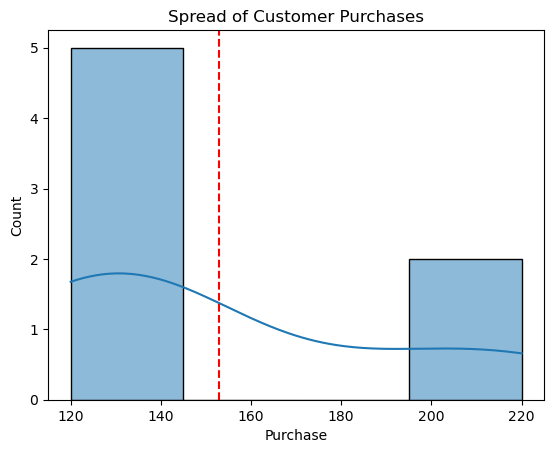

In [41]:
import seaborn as sns 
import matplotlib.pyplot as plt 
sns.histplot(data=df,x='Purchase', kde=True)
plt.axvline(mean1, color='red', linestyle='dashed', label='mean1')
plt.legend
plt.title('Spread of Customer Purchases')

# 3. Percentile , quartile, IQR , z-score

In [57]:
import numpy as np
data = [10, 12, 13, 15, 18, 21, 23, 25, 28, 30, 34, 35, 37, 40]

In [56]:
print('q1:',np.percentile(data,25))
print('q2',np.percentile(data,50))
print('q3',np.percentile(data,75))


q1: 15.75
q2 24.0
q3 33.0


In [ ]:
Q1 = np.percentile(data, 25)
Q3 = np.percentile(data, 75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("IQR:", IQR)
print("Outlier Range:", lower_bound, "to", upper_bound)

In [63]:
q1=np.percentile(data,25)
q3=np.percentile(data,75)
IQR=q3-q1
print('iqr',IQR)
lower_bound=q1-1.5*IQR
upper_bound=q3+1.5*IQR
print("Outlier Range:", lower_bound, "to", upper_bound)

iqr 17.25
Outlier Range: -10.125 to 58.875


In [64]:
data = np.array([10, 12, 13, 15, 18, 21, 23, 25, 28, 30, 34, 35, 37, 40])
mean = np.mean(data)
std = np.std(data)
z_scores = [(x - mean) / std for x in data]
print("z-scores:", np.round(z_scores, 2))

z-scores: [-1.5  -1.29 -1.19 -0.98 -0.66 -0.35 -0.14  0.07  0.38  0.59  1.01  1.11
  1.32  1.63]


In [112]:
import numpy as np
df=pd.DataFrame({'Income':[22, 25, 27, 29, 35, 40, 42, 100, 110, 115,400]})
q1 = df['Income'].quantile(0.25)
q3=df['Income'].quantile(0.75)
print(q1,q3)
IQR=q3-q1
lower=q1-1.0*IQR
upper=q3+1.0*IQR
print('outlier range:',lower, upper)
outlier_iqr=df[(df['Income']<lower) | (df['Income'] > upper)]
print('outlier:',outlier_iqr)

#z-score
mean=df['Income'].mean()
std=df['Income'].std()
df['z-score']=(df['Income']-mean)/std 
outlier_z=df[np.abs(df['z-score'])>2.5]
print(df['z-score'])
print('z-score outlier:',outlier_z)

median=df['Income'].median()
mad=np.median(np.abs(df['Income']-median))
print('mad and median',mad,median)
df['mod_z_score']=0.6745* (df['Income']-median/mad)
outliers_mz = df[np.abs(df['mod_z_score']) > 3.5]
print("Outliers using Modified Z-score:\n", outliers_mz)

28.0 105.0
outlier range: -49.0 182.0
outlier:     Income
10     400
0    -0.580013
1    -0.552786
2    -0.534635
3    -0.516483
4    -0.462030
5    -0.416652
6    -0.398501
7     0.127883
8     0.218639
9     0.264017
10    2.850559
Name: z-score, dtype: float64
z-score outlier:     Income   z-score
10     400  2.850559
mad and median 15.0 40.0
Outliers using Modified Z-score:
     Income   z-score  mod_z_score
0       22 -0.580013    13.040333
1       25 -0.552786    15.063833
2       27 -0.534635    16.412833
3       29 -0.516483    17.761833
4       35 -0.462030    21.808833
5       40 -0.416652    25.181333
6       42 -0.398501    26.530333
7      100  0.127883    65.651333
8      110  0.218639    72.396333
9      115  0.264017    75.768833
10     400  2.850559   268.001333
